<a href="https://colab.research.google.com/github/maxsccavalcante/FabricaSoftware/blob/main/AnaliseDados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files

uploaded = files.upload()
uploaded.keys()

df = pd.read_csv('car data.csv', sep=',')
df
df.head(),
df.tail()
df.info()
df.describe()
df.isnull().sum()
df.isna().sum()


Saving car data.csv to car data (1).csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [58]:
df.describe()
df['Fuel_Type'].value_counts()
df['Selling_type'].value_counts()
df['Transmission'].value_counts()
df['Owner'].value_counts()

df.duplicated().sum()

df = df.drop_duplicates()

df.duplicated().sum()

df.dtypes

df.info()

print("Selling_Price negativos:", (df['Selling_Price'] < 0).sum())
print("Present_Price negativos:", (df['Present_Price'] < 0).sum())
print("Driven_kms negativos:", (df['Driven_kms'] < 0).sum())
print("Year negativos:", (df['Year'] < 0).sum())

df.head()

df.shape

print("Valores ausentes:")
print(df.isnull().sum())

print("\nLinhas duplicadas:")
print(df.duplicated().sum())

print("\nTipos das colunas:")
print(df.dtypes)

print("\nInformações do dataset:")
df.info()

print("\nCategorias de Fuel_Type:")
print(df['Fuel_Type'].unique())

print("\nCategorias de Selling_type:")
print(df['Selling_type'].unique())

print("\nCategorias de Transmission:")
print(df['Transmission'].unique())

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

categorical_columns = ['Fuel_Type', 'Selling_type', 'Transmission']

encoded_data = encoder.fit_transform(df[categorical_columns])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=df.index
)

encoded_df.head()


<class 'pandas.core.frame.DataFrame'>
Index: 299 entries, 0 to 300
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       299 non-null    object 
 1   Year           299 non-null    int64  
 2   Selling_Price  299 non-null    float64
 3   Present_Price  299 non-null    float64
 4   Driven_kms     299 non-null    int64  
 5   Fuel_Type      299 non-null    object 
 6   Selling_type   299 non-null    object 
 7   Transmission   299 non-null    object 
 8   Owner          299 non-null    int64  
 9   Car_Age        299 non-null    int64  
 10  Km_per_Year    299 non-null    float64
 11  Is_Automatic   299 non-null    int64  
 12  Is_Dealer      299 non-null    int64  
dtypes: float64(3), int64(6), object(4)
memory usage: 32.7+ KB
Selling_Price negativos: 0
Present_Price negativos: 0
Driven_kms negativos: 0
Year negativos: 0
Valores ausentes:
Car_Name         0
Year             0
Selling_Price    0
Presen

,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Dealer,Selling_type_Individual,Transmission_Automatic,Transmission_Manual
0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,0.0,1.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,1.0,1.0,0.0,0.0,1.0
3,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,0.0,1.0,0.0,1.0,0.0,0.0,1.0


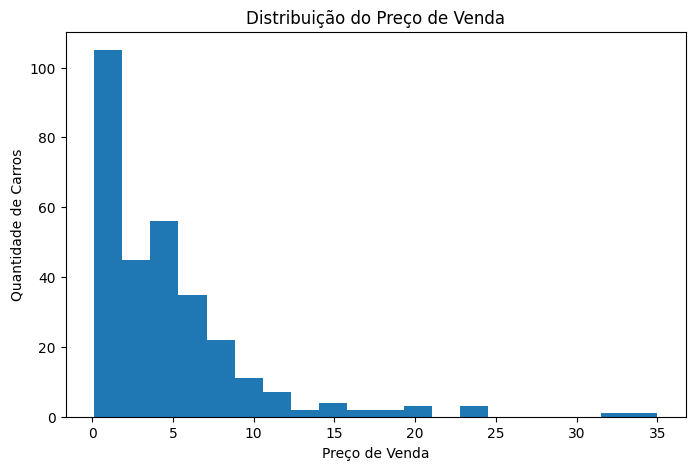

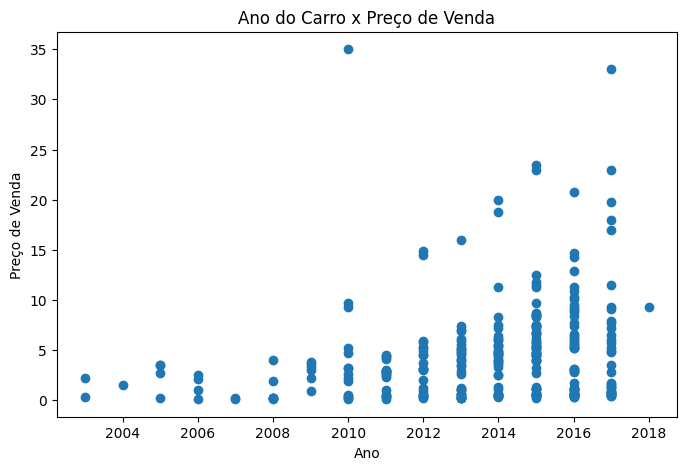

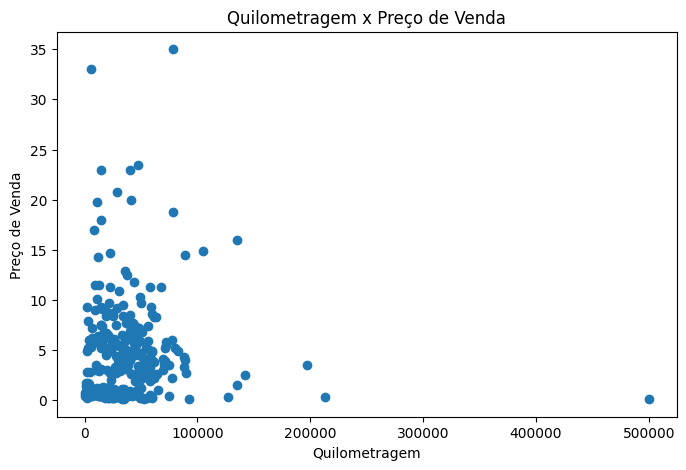

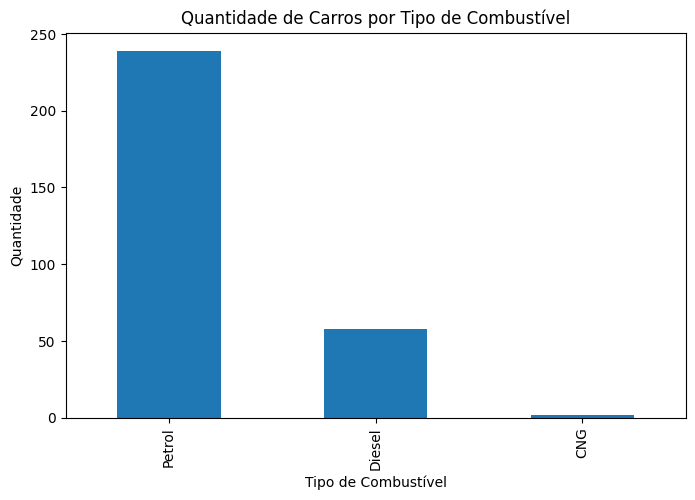

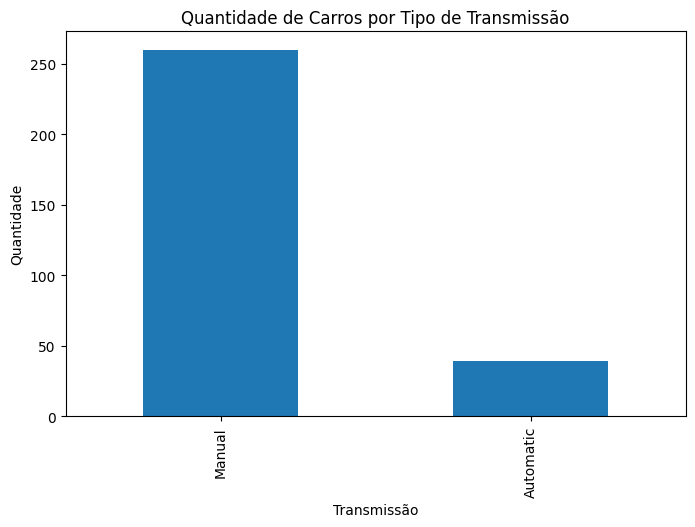

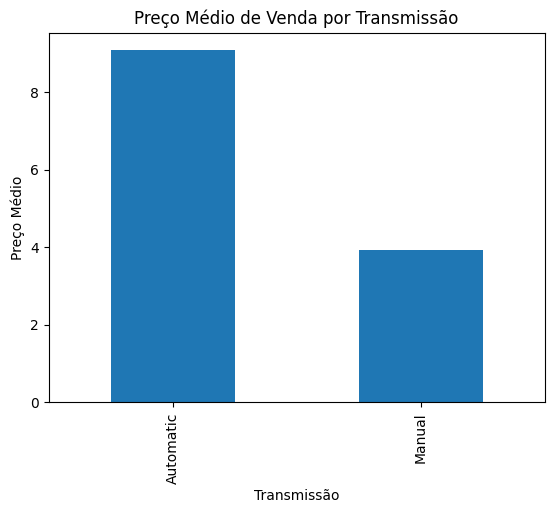

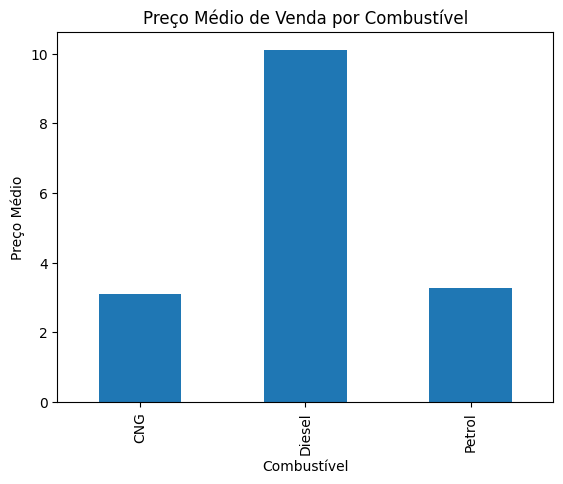

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Km_per_Year,Is_Automatic,Is_Dealer
Year,1.000000,0.234369,-0.053167,-0.525714,-0.181639,-1.000000,-0.052215,-0.003434,0.036820
Selling_Price,0.234369,1.000000,0.876305,0.028566,-0.087880,-0.234369,0.257040,0.348869,0.553851
Present_Price,-0.053167,0.876305,1.000000,0.205224,0.009948,0.053167,0.283229,0.334326,0.511779
Driven_kms,-0.525714,0.028566,0.205224,1.000000,0.089367,0.525714,0.774222,0.163881,0.101030
Owner,-0.181639,-0.087880,0.009948,0.089367,1.000000,0.181639,-0.025301,0.052166,-0.123646
Car_Age,-1.000000,-0.234369,0.053167,0.525714,0.181639,1.000000,0.052215,0.003434,-0.036820
Km_per_Year,-0.052215,0.257040,0.283229,0.774222,-0.025301,0.052215,1.000000,0.158047,0.265838
Is_Automatic,-0.003434,0.348869,0.334326,0.163881,0.052166,0.003434,0.158047,1.000000,0.058669
Is_Dealer,0.036820,0.553851,0.511779,0.101030,-0.123646,-0.036820,0.265838,0.058669,1.000000


In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(df['Selling_Price'], bins=20)

plt.title('Distribuição do Preço de Venda')
plt.xlabel('Preço de Venda')
plt.ylabel('Quantidade de Carros')

plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(df['Year'], df['Selling_Price'])

plt.title('Ano do Carro x Preço de Venda')
plt.xlabel('Ano')
plt.ylabel('Preço de Venda')

plt.show()


plt.figure(figsize=(8, 5))

plt.scatter(df['Driven_kms'], df['Selling_Price'])

plt.title('Quilometragem x Preço de Venda')
plt.xlabel('Quilometragem')
plt.ylabel('Preço de Venda')

plt.show()

plt.figure(figsize=(8, 5))

df['Fuel_Type'].value_counts().plot(kind='bar')

plt.title('Quantidade de Carros por Tipo de Combustível')
plt.xlabel('Tipo de Combustível')
plt.ylabel('Quantidade')

plt.show()

plt.figure(figsize=(8, 5))

df['Transmission'].value_counts().plot(kind='bar')

plt.title('Quantidade de Carros por Tipo de Transmissão')
plt.xlabel('Transmissão')
plt.ylabel('Quantidade')

plt.show()

df.groupby('Transmission')['Selling_Price'].mean().plot(kind='bar')

plt.title('Preço Médio de Venda por Transmissão')
plt.xlabel('Transmissão')
plt.ylabel('Preço Médio')

plt.show()

df.groupby('Fuel_Type')['Selling_Price'].mean().plot(kind='bar')

plt.title('Preço Médio de Venda por Combustível')
plt.xlabel('Combustível')
plt.ylabel('Preço Médio')

plt.show()

df.corr(numeric_only=True)

In [55]:
df['Is_Dealer'] = (df['Selling_type'] == 'Dealer').astype(int)
df[['Selling_type', 'Is_Dealer']].head(10)

,Selling_type,Is_Dealer
0,Dealer,1
1,Dealer,1
2,Dealer,1
3,Dealer,1
4,Dealer,1
5,Dealer,1
6,Dealer,1
7,Dealer,1
8,Dealer,1
9,Dealer,1


In [52]:
df['Car_Age'] = 2018 - df['Year']
df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2014,4
1,2013,5
2,2017,1
3,2011,7
4,2014,4


In [53]:
df['Km_per_Year'] = df['Driven_kms'] / (df['Car_Age'] + 1)
df['Km_per_Year'] = df['Km_per_Year'].round(2)
df[['Driven_kms', 'Car_Age', 'Km_per_Year']].head()

,Driven_kms,Car_Age,Km_per_Year
0,27000,4,5400.00
1,43000,5,7166.67
2,6900,1,3450.00
3,5200,7,650.00
4,42450,4,8490.00


In [54]:
df['Is_Automatic'] = (df['Transmission'] == 'Automatic').astype(int)
df[['Transmission', 'Is_Automatic']].head(10)

,Transmission,Is_Automatic
0,Manual,0
1,Manual,0
2,Manual,0
3,Manual,0
4,Manual,0
5,Manual,0
6,Manual,0
7,Manual,0
8,Manual,0
9,Manual,0
